# Support Ticket Classifier and Prioritization

**Dataset:** IT Helpdesk Support Tickets from Zenodo  
**Goal:** Predict ticket category + priority from text  
**Method:** Text cleaning → TF-IDF → ML models

---

### What this project does

IT helpdesks get a lot of tickets every day. Someone has to read each one, figure out which team should handle it, and decide how urgent it is. That's a lot of manual work. I wanted to see if I can automate this with ML.

Given the text of a support ticket, my model tries to predict:
1. **Category** — which team handles it? (like O365 team, Active Directory team, etc.)
2. **Priority** — how urgent? (High / Medium / Low)

### About the dataset

I downloaded this from Zenodo. It's real helpdesk data, already split into train and test. There are 4 CSV files:

| File | Contents |
|---|---|
| `X_train.csv` | ticket id + text (1572 tickets) |
| `X_test.csv` | ticket id + text (657 tickets) |
| `y_train.csv` | ticket id + category label |
| `y_test.csv` | ticket id + category label |

**7 categories:** Active Directory, Computer-Services, EOL, Fileservice, O365, Software, Support general

> **Note:** The dataset doesn't have a priority column. I made my own priority labels using some rules — explained in Step 2.

---
## Step 0 — Importing Libraries

In [26]:
# !pip install scikit-learn nltk pandas matplotlib seaborn joblib

import pandas as pd
import numpy as np
import re
import os
import time
import warnings
warnings.filterwarnings("ignore")

import matplotlib.pyplot as plt
import seaborn as sns

import nltk
nltk.download("stopwords", quiet=True)
nltk.download("punkt_tab", quiet=True)
nltk.download("wordnet",   quiet=True)

from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, precision_recall_fscore_support
)
from sklearn.model_selection import cross_val_score
import joblib

os.makedirs("charts", exist_ok=True)
os.makedirs("models", exist_ok=True)

print("libraries loaded!")

libraries loaded!


---
## Step 1 — Loading the Data

Both X and y files share an `id` column, so I merge them on that to combine text and labels into one dataframe.

In [27]:
# load datasets
X_train_raw = pd.read_csv("X_train.csv")
y_train_raw = pd.read_csv("y_train.csv")
X_test_raw  = pd.read_csv("X_test.csv")
y_test_raw  = pd.read_csv("y_test.csv")

# merge using the id column
train = X_train_raw.merge(y_train_raw, on="id")
test  = X_test_raw.merge(y_test_raw,   on="id")

CATEGORIES = sorted(train["category_truth"].unique())

print(f"train size: {len(train)}")
print(f"test size : {len(test)}")
print(f"categories: {CATEGORIES}")
train.head(3)

train size: 1572
test size : 657
categories: ['Active Directory', 'Computer-Services', 'EOL', 'Fileservice', 'O365', 'Software', 'Support general']


,id,text,category_truth
0,1919,File Share Access - [TICKET ID] - [NAME]. [NAM...,Fileservice
1,1584,File Share Access - [TICKET ID] - [NAME] ([COM...,Fileservice
2,584,[TICKET ID] - A Support Ticket was forwarded t...,Support general


In [28]:
# Check for missing values
print("Missing values in training set:")
print(train[["text", "category_truth"]].isnull().sum())

print("\nCategory distribution (train):")
print(train["category_truth"].value_counts())

Missing values in training set:
text              0
category_truth    0
dtype: int64

Category distribution (train):
category_truth
Fileservice          546
Support general      541
Software             164
O365                 127
Active Directory      84
Computer-Services     65
EOL                   45
Name: count, dtype: int64


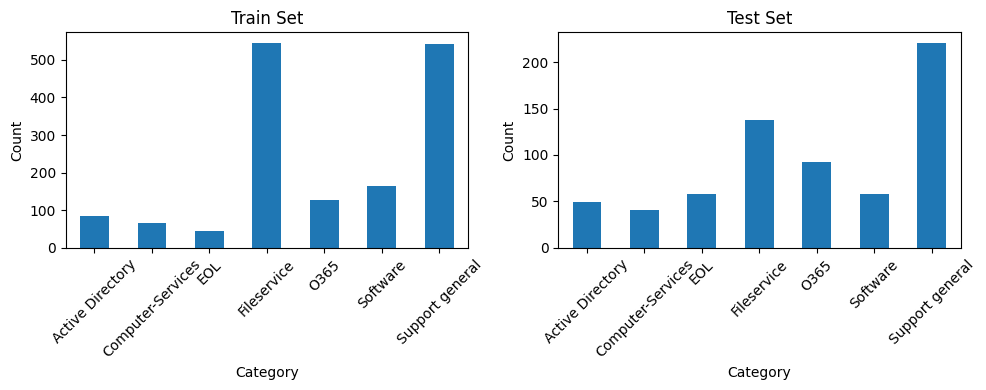

In [29]:
# Visualise the category distribution
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

train["category_truth"].value_counts().reindex(CATEGORIES).plot(
    kind="bar", ax=axes[0]
)
axes[0].set_title("Train Set")

test["category_truth"].value_counts().reindex(CATEGORIES).plot(
    kind="bar", ax=axes[1]
)
axes[1].set_title("Test Set")

for ax in axes:
    ax.set_xlabel("Category")
    ax.set_ylabel("Count")
    ax.tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

**What I noticed:** The data is pretty unbalanced. `Fileservice` and `Support general` together are like 70% of the training data, but `EOL` only has 45 tickets. This is a problem because the model will probably just learn to always predict the big classes. I'll deal with this in step 5 using `class_weight='balanced'`.

---
## Step 2 — Creating Priority Labels

The dataset only has category labels, not priority. But in a real helpdesk every ticket gets a priority too, so I had to make them myself.

I thought about what makes each category urgent:
- **Active Directory** — if someone can't log in, they literally can't work. That's High.
- **EOL** — End of Life systems are a security risk. High.
- **O365 / Software / Fileservice** — important but usually not on fire. Medium.
- **Computer-Services / Support general** — printers and general requests can wait. Low.

I also added a keyword check — if the ticket text has words like "critical" or "down", I upgrade the priority. I never downgrade, only upgrade.

| Priority | Category | Why |
|---|---|---|
| High | EOL, Active Directory | Blocks work or security risk |
| Medium | O365, Software, Fileservice | Has workarounds usually |
| Low | Computer-Services, Support general | Not urgent |

In [30]:
# priority mapping
PRIORITY_RULES = {
    "EOL"               : "High",    # End-of-Life = security/compliance risk
    "Active Directory"  : "High",    # Access issues block employees immediately
    "O365"              : "Medium",  # Email issues are important but rarely critical
    "Software"          : "Medium",  # Software problems usually have workarounds
    "Fileservice"       : "Medium",  # File access affects productivity
    "Computer-Services" : "Low",     # Hardware issues like printers can often wait
    "Support general"   : "Low",     # Generic requests, typically non-urgent
}

# if these words appear in the text, upgrade priority
KEYWORD_BOOST = {
    "urgent"        : "High",
    "critical"      : "High",
    "cannot login"  : "High",
    "down"          : "High",
    "not working"   : "High",
    "blocked"       : "High",
    "access denied" : "High",
    "password"      : "Medium",
    "install"       : "Medium",
}


def assign_priority(row):
    base = PRIORITY_RULES.get(row["category_truth"], "Low")
    text_lower = str(row["text"]).lower()
    priority_scale = {"High": 2, "Medium": 1, "Low": 0}

    # upgrade 
    for keyword, boosted_priority in KEYWORD_BOOST.items():
        if keyword in text_lower:
            if priority_scale[boosted_priority] > priority_scale[base]:
                base = boosted_priority

    return base


train["priority"] = train.apply(assign_priority, axis=1)
test["priority"]  = test.apply(assign_priority, axis=1)

print("Priority counts in training set:")
print(train["priority"].value_counts())
print()
train[["text", "category_truth", "priority"]].sample(6, random_state=42)

Priority counts in training set:
priority
Medium    838
Low       572
High      162
Name: count, dtype: int64



,text,category_truth,priority
1120,Shared Mailbox Access - [AWS_ACCESS_KEY] - [EM...,Support general,Low
810,[TICKET ID] - A Support Ticket was forwarded t...,Software,Medium
1170,File Share Access - [TICKET ID] - [NAME] ([COM...,Fileservice,Medium
534,File Share Access - [TICKET ID] - [NAME] ([COM...,Fileservice,Medium
514,Local admin rights needed for [SERVER],Active Directory,High
1521,File Share Access - [TICKET ID] - Knoll. Natal...,Fileservice,Medium


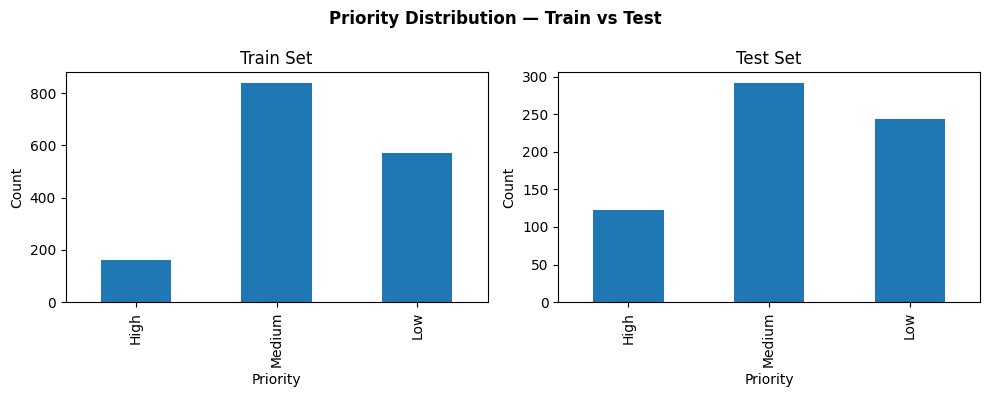

In [31]:
# plot priority distribution
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
fig.suptitle("Priority Distribution — Train vs Test", fontweight="bold")

train["priority"].value_counts().reindex(["High", "Medium", "Low"]).plot(
    kind="bar", ax=axes[0]
)
axes[0].set_title("Train Set")

test["priority"].value_counts().reindex(["High", "Medium", "Low"]).plot(
    kind="bar", ax=axes[1]
)
axes[1].set_title("Test Set")

for ax in axes:
    ax.set_xlabel("Priority")
    ax.set_ylabel("Count")

plt.tight_layout()
plt.show()

---
## Step 3 — Cleaning the Text

The raw ticket text has a lot of noise. After looking at a few examples I noticed:

- **`[PLACEHOLDER]` tokens** like `[NAME]`, `[SERVER]` — these are the same in every ticket, so they don't help the model at all
- **Boilerplate phrases** — things like "A Support Ticket was forwarded to your role" appear everywhere
- **Non-English text** — some tickets are in Portuguese, but my stopwords are English
- **URLs, emails, numbers, punctuation** — not useful for topic classification

My cleaning steps:
1. Lowercase
2. Remove `[PLACEHOLDER]` tokens
3. Remove URLs, emails, numbers, punctuation
4. Tokenize
5. Remove stopwords + some domain-specific junk words
6. Lemmatize (so "installing" and "installed" both become "install")

In [32]:
stop_words = set(stopwords.words("english"))

# Add domain-specific noise words 
domain_noise = {
    "ticket", "support", "request", "please", "forwarded",
    "role", "new", "received", "subject", "automated", "creation"
}
stop_words = stop_words.union(domain_noise)

lemmatizer = WordNetLemmatizer()


def clean_text(raw_text):
    if not isinstance(raw_text, str):
        return ""

    text = raw_text.lower()
    text = re.sub(r"\[.*?\]", " ", text)               # remove [PLACEHOLDER] tokens
    text = re.sub(r"https?://\S+|www\.\S+", " ", text)  # remove URLs
    text = re.sub(r"\S+@\S+", " ", text)                # remove emails
    text = re.sub(r"\d+", " ", text)                     # remove numbers
    text = re.sub(r"[^a-z\s]", " ", text)                # remove punctuation
    text = re.sub(r"\s+", " ", text).strip()             # remove extra spaces

    tokens = word_tokenize(text)
    tokens = [t for t in tokens if t not in stop_words and len(t) > 2]
    tokens = [lemmatizer.lemmatize(t) for t in tokens]

    return " ".join(tokens)


print("cleaning train text...")
train["clean_text"] = train["text"].apply(clean_text)
print("cleaning test text...")
test["clean_text"]  = test["text"].apply(clean_text)
print("done!")

# few examples
print()
for idx in [0, 4, 8]:
    raw   = train["text"].iloc[idx][:130].replace("\n", " ")
    clean = train["clean_text"].iloc[idx][:130]
    label = train["category_truth"].iloc[idx]
    print(f"[{label}]")
    print(f"  BEFORE: {raw}")
    print(f"  AFTER : {clean}")
    print()

cleaning train text...
cleaning test text...
done!

[Fileservice]
  BEFORE: File Share Access - [TICKET ID] - [NAME]. [NAME] ([COMPANY]. [LOCATION])
  AFTER : file share access

[Fileservice]
  BEFORE: LVS not respondingLVS will not except my password to let me log on. 
  AFTER : lvs respondinglvs except password let log

[Software]
  BEFORE: Java Installation on [SERVER]
  AFTER : java installation



---
## Step 4 — TF-IDF Feature Extraction

ML models need numbers, not text. TF-IDF converts each ticket into a vector of numbers.

**How TF-IDF works:**
- TF = how often a word appears in this ticket
- IDF = how rare is this word across all tickets (rare words get higher scores)
- TF-IDF = TF × IDF → words that are common in one ticket but rare overall get high scores

For example, the word `"nexthink"` appears a lot in EOL tickets but almost nowhere else — so it gets a high score for EOL. The word `"the"` appears everywhere, so IDF brings its score close to zero.

I also used `ngram_range=(1, 2)` which means it considers both single words AND word pairs like `"active directory"` or `"file share"`. These pairs carry more meaning than the individual words.

In [33]:
tfidf = TfidfVectorizer(
    max_features=5000,   # top 5000 features only
    ngram_range=(1, 2),  # single words + bigrams (word pairs)
    sublinear_tf=True,   # log scaling to reduce very common words
    min_df=2,            # ignore words that appear in less than 2 tickets
    max_df=0.90,         # ignore words that appear in more than 90% of tickets
)

# fit on training data only
X_tr = tfidf.fit_transform(train["clean_text"].fillna(""))

# only .transform() on test
X_te = tfidf.transform(test["clean_text"].fillna(""))

y_tr_cat = train["category_truth"]
y_te_cat = test["category_truth"]
y_tr_pri = train["priority"]
y_te_pri = test["priority"]

print(f"train matrix shape: {X_tr.shape}")
print(f"test matrix shape : {X_te.shape}")

joblib.dump(tfidf, "models/tfidf_vectorizer.pkl")
print("\nvectorizer saved!")

train matrix shape: (1572, 1299)
test matrix shape : (657, 1299)

vectorizer saved!


In [34]:
# the top words for each category 
feature_names = np.array(tfidf.get_feature_names_out())
print("Top 10 TF-IDF terms per category:\n")

for cat in CATEGORIES:
    mask = (y_tr_cat == cat).values
    cat_matrix = X_tr[mask]
    mean_scores = np.asarray(cat_matrix.mean(axis=0)).flatten()
    top_idx = mean_scores.argsort()[::-1][:10]
    print(f"  [{cat}]")
    print(f"    {', '.join(feature_names[top_idx])}")
    print()

Top 10 TF-IDF terms per category:

  [Active Directory]
    user, schen, acesso, account, change, access, employee, group, needed, leaving employee

  [Computer-Services]
    impressora, printer, instala, impresora, scanner, instalar, computador, com, install printer, print

  [EOL]
    reservation, remove, nexthink, system, life nexthink, must set, life, system must, following system, set end

  [Fileservice]
    share, file share, file, share access, access, access file, following user, comment, grant, grant access

  [O365]
    skype, email, mail, excel, access, power, working, outlook, onedrive, mailbox

  [Software]
    missing, missing connection, connection, initiated, system, connection securitytools, securitytools, securitytools system, initiated git, git missing

  [Support general]
    mailbox, shared mailbox, shared, mailbox access, access, user, basis user, basis, create, create shared



---
## Step 5 — Training the Models

I tried 3 different classifiers to see which one works best:

| Model | Why I tried it |
|---|---|
| **Logistic Regression** | Simple and easy to understand. Good baseline for text classification. |
| **Multinomial Naive Bayes** | Made for word frequency data. Really fast. |
| **Linear SVM** | Usually does well on high-dimensional sparse data like TF-IDF. |

I used `class_weight='balanced'` for LR and SVM because the data is imbalanced — this makes the model pay more attention to the smaller classes.

I also did 5-fold cross-validation to get a better estimate of accuracy (instead of just checking on the test set once).

In [35]:
# Category Classification 

def build_cat_models():
    return {
        "Logistic Regression": LogisticRegression(
            max_iter=1000, C=1.0, class_weight="balanced", random_state=42
        ),
        "Multinomial Naive Bayes": MultinomialNB(alpha=0.5),
        "Linear SVM": LinearSVC(
            C=1.0, class_weight="balanced", random_state=42, max_iter=2000
        ),
    }


cat_results = {}
print("Training category models...\n")
print(f"{'Model':<28}  {'Test Acc':>9}  {'CV Mean':>9}  {'CV Std':>8}  {'Time':>6}")
print("-" * 68)

for name, clf in build_cat_models().items():
    t0 = time.time()
    clf.fit(X_tr, y_tr_cat)
    preds     = clf.predict(X_te)
    test_acc  = accuracy_score(y_te_cat, preds)
    cv_scores = cross_val_score(clf, X_tr, y_tr_cat, cv=5, scoring="accuracy")
    elapsed   = time.time() - t0
    cat_results[name] = {
        "model"   : clf,
        "preds"   : preds,
        "test_acc": test_acc,
        "cv_mean" : cv_scores.mean(),
        "cv_std"  : cv_scores.std(),
    }
    print(f"{name:<28}  {test_acc:>9.4f}  {cv_scores.mean():>9.4f}  "
          f"{cv_scores.std():>8.4f}  {elapsed:>5.1f}s")

best_cat_name  = max(cat_results, key=lambda n: cat_results[n]["test_acc"])
best_cat_model = cat_results[best_cat_name]["model"]
best_cat_preds = cat_results[best_cat_name]["preds"]

print(f"\nbest model: {best_cat_name}")
joblib.dump(best_cat_model, "models/best_category_model.pkl")
print("model saved!")

Training category models...

Model                          Test Acc    CV Mean    CV Std    Time
--------------------------------------------------------------------
Logistic Regression              0.7747     0.7863    0.0054    0.6s
Multinomial Naive Bayes          0.7519     0.8136    0.0166    0.0s
Linear SVM                       0.8189     0.8283    0.0114    0.2s

best model: Linear SVM
model saved!


In [36]:
# Priority Classification

def build_pri_models():
    return {
        "Logistic Regression": LogisticRegression(
            max_iter=1000, C=1.0, class_weight="balanced", random_state=42
        ),
        "Multinomial Naive Bayes": MultinomialNB(alpha=0.5),
        "Linear SVM": LinearSVC(
            C=1.0, class_weight="balanced", random_state=42, max_iter=2000
        ),
    }


pri_results = {}
print("Training priority models...\n")
print(f"{'Model':<28}  {'Test Acc':>9}  {'CV Mean':>9}  {'CV Std':>8}  {'Time':>6}")
print("-" * 68)

for name, clf in build_pri_models().items():
    t0 = time.time()
    clf.fit(X_tr, y_tr_pri)
    preds     = clf.predict(X_te)
    test_acc  = accuracy_score(y_te_pri, preds)
    cv_scores = cross_val_score(clf, X_tr, y_tr_pri, cv=5, scoring="accuracy")
    elapsed   = time.time() - t0
    pri_results[name] = {
        "model"   : clf,
        "preds"   : preds,
        "test_acc": test_acc,
        "cv_mean" : cv_scores.mean(),
        "cv_std"  : cv_scores.std(),
    }
    print(f"{name:<28}  {test_acc:>9.4f}  {cv_scores.mean():>9.4f}  "
          f"{cv_scores.std():>8.4f}  {elapsed:>5.1f}s")

best_pri_name  = max(pri_results, key=lambda n: pri_results[n]["test_acc"])
best_pri_model = pri_results[best_pri_name]["model"]
best_pri_preds = pri_results[best_pri_name]["preds"]

print(f"\nbest model: {best_pri_name}")
joblib.dump(best_pri_model, "models/best_priority_model.pkl")
print("model saved!")

Training priority models...

Model                          Test Acc    CV Mean    CV Std    Time
--------------------------------------------------------------------
Logistic Regression              0.8097     0.8473    0.0156    0.4s
Multinomial Naive Bayes          0.7793     0.8544    0.0189    0.1s
Linear SVM                       0.8341     0.8543    0.0082    0.1s

best model: Linear SVM
model saved!


#### Why SVM Performed Best

TF-IDF creates thousands of features, but most of them are zero for any given ticket. SVM handles this kind of high-dimensional sparse data very well, allowing it to identify the most important features for classification.

#### Why Naive Bayes Shows Different CV and Test Scores

Naive Bayes assumes that all words are independent of each other, which is not always true in real text data. Words often appear together and carry related meaning. Because of this simplification, Naive Bayes can perform well during cross-validation but may show slightly different results on the test set.


---
## Step 6 — Evaluating the Models

**Metrics I'm looking at:**
- **Accuracy** — how many tickets did the model get right overall
- **Precision** — of all tickets predicted as class X, how many were actually X
- **Recall** — of all tickets that are class X, how many did the model catch
- **F1-score** — combination of precision and recall. Better metric than accuracy when classes are unequal in size

In [37]:
# classification report for category prediction
print(f"=== Category Report — {best_cat_name} ===\n")
print(classification_report(y_te_cat, best_cat_preds,
                             target_names=CATEGORIES, zero_division=0))

=== Category Report — Linear SVM ===

                   precision    recall  f1-score   support

 Active Directory       0.51      0.53      0.52        49
Computer-Services       0.81      0.71      0.75        41
              EOL       1.00      1.00      1.00        58
      Fileservice       0.93      0.96      0.95       138
             O365       0.79      0.71      0.75        92
         Software       0.68      0.62      0.65        58
  Support general       0.82      0.86      0.84       221

         accuracy                           0.82       657
        macro avg       0.79      0.77      0.78       657
     weighted avg       0.82      0.82      0.82       657



In [38]:
# classification report for priority prediction
print(f"=== Priority Report — {best_pri_name} ===\n")
print(classification_report(y_te_pri, best_pri_preds,
                             labels=["High", "Medium", "Low"],
                             target_names=["High", "Medium", "Low"],
                             zero_division=0))

=== Priority Report — Linear SVM ===

              precision    recall  f1-score   support

        High       0.79      0.79      0.79       122
      Medium       0.90      0.82      0.86       291
         Low       0.79      0.88      0.83       244

    accuracy                           0.83       657
   macro avg       0.83      0.83      0.83       657
weighted avg       0.84      0.83      0.83       657



### Chart 1 — Model Comparison

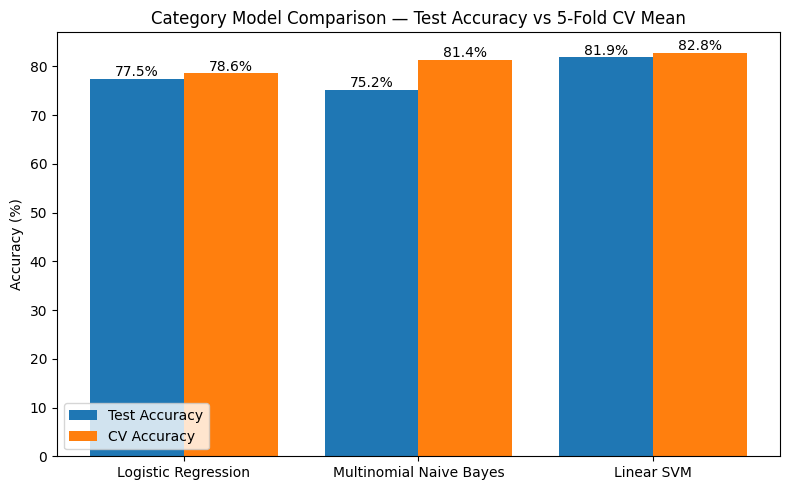

In [39]:
model_names = list(cat_results.keys())
test_accs = [cat_results[n]["test_acc"] * 100 for n in model_names]
cv_means = [cat_results[n]["cv_mean"] * 100 for n in model_names]

x = np.arange(len(model_names))
w = 0.4

fig, ax = plt.subplots(figsize=(8, 5))

bars1 = ax.bar(x - w/2, test_accs, w, label="Test Accuracy")
bars2 = ax.bar(x + w/2, cv_means, w, label="CV Accuracy")

ax.set_xticks(x)
ax.set_xticklabels(model_names)
ax.set_ylabel("Accuracy (%)")
ax.set_title("Category Model Comparison — Test Accuracy vs 5-Fold CV Mean")
ax.legend()

for bar in list(bars1) + list(bars2):
    ax.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.5,
        f"{bar.get_height():.1f}%",
        ha="center"
    )

plt.tight_layout()
plt.show()

### Chart 2 — Confusion Matrix (Category)

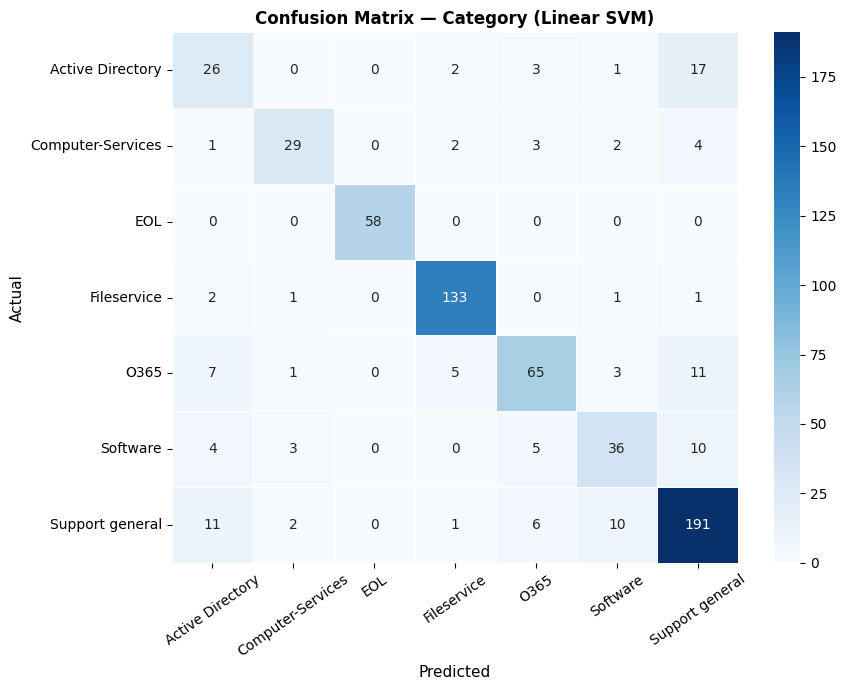

Diagonal = correct predictions. Off-diagonal = mistakes.


In [40]:
cm = confusion_matrix(y_te_cat, best_cat_preds, labels=CATEGORIES)

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=CATEGORIES, yticklabels=CATEGORIES,
            ax=ax, linewidths=0.5, linecolor="white")
ax.set_title(f"Confusion Matrix — Category ({best_cat_name})",
             fontsize=12, fontweight="bold")
ax.set_xlabel("Predicted", fontsize=11)
ax.set_ylabel("Actual", fontsize=11)
ax.tick_params(axis="x", rotation=35)
ax.tick_params(axis="y", rotation=0)
plt.tight_layout()
plt.savefig("charts/04_confusion_matrix.png", dpi=120, bbox_inches="tight")
plt.show()
print("Diagonal = correct predictions. Off-diagonal = mistakes.")

**What I see in the confusion matrix:**
- EOL is almost perfect — it has unique words like "nexthink" that appear nowhere else
- Software and Support general get mixed up a lot — both can have generic IT language
- Active Directory and Computer-Services have lower recall because they have fewer training examples (84 and 65 tickets)

### Chart 3 — Precision / Recall / F1 per Category

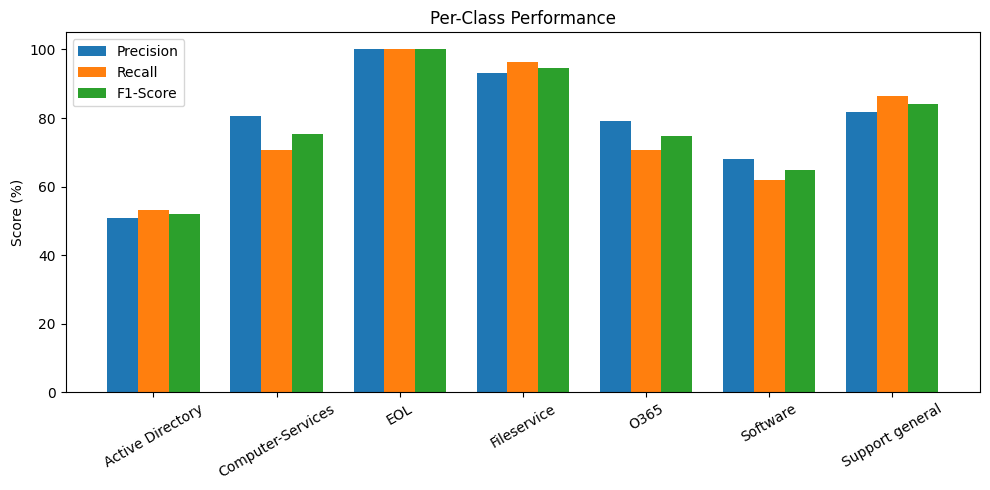

In [41]:
precision, recall, f1, _ = precision_recall_fscore_support(
    y_te_cat, best_cat_preds, labels=CATEGORIES, zero_division=0
)

x = np.arange(len(CATEGORIES))
width = 0.25

fig, ax = plt.subplots(figsize=(10, 5))

ax.bar(x - width, precision * 100, width, label="Precision")
ax.bar(x, recall * 100, width, label="Recall")
ax.bar(x + width, f1 * 100, width, label="F1-Score")

ax.set_xticks(x)
ax.set_xticklabels(CATEGORIES, rotation=30)
ax.set_ylabel("Score (%)")
ax.set_title("Per-Class Performance")
ax.legend()

plt.tight_layout()
plt.show()

### Chart 4 — Confusion Matrix (Priority)

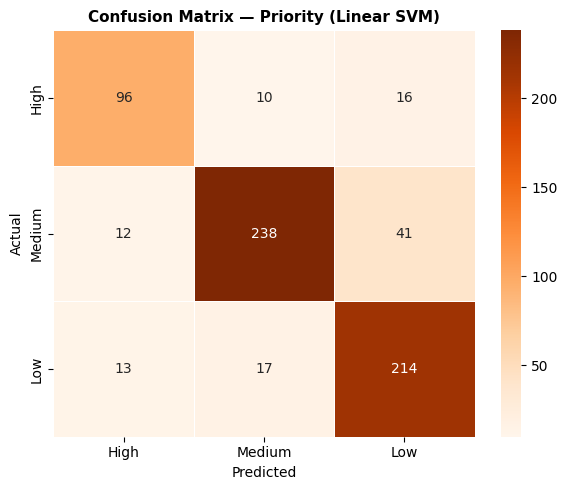

In [42]:
cm_pri = confusion_matrix(y_te_pri, best_pri_preds,
                           labels=["High", "Medium", "Low"])

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm_pri, annot=True, fmt="d", cmap="Oranges",
            xticklabels=["High","Medium","Low"],
            yticklabels=["High","Medium","Low"],
            ax=ax, linewidths=0.5, linecolor="white")
ax.set_title(f"Confusion Matrix — Priority ({best_pri_name})",
             fontsize=11, fontweight="bold")
ax.set_xlabel("Predicted")
ax.set_ylabel("Actual")
plt.tight_layout()
plt.savefig("charts/06_priority_confusion_matrix.png", dpi=120, bbox_inches="tight")
plt.show()

---
## Step 7 — Predicting on New Tickets

Now I put everything into one function. You give it a raw ticket text, it cleans it, runs TF-IDF, and gives you the predicted category + priority + which team to route it to.

In [43]:
# which team handles each category
ROUTING = {
    "Fileservice"       : "Storage & File-Share Team",
    "Support general"   : "General Helpdesk",
    "Software"          : "Software & Applications Team",
    "EOL"               : "Infrastructure / Asset Management",
    "O365"              : "Microsoft 365 Team",
    "Active Directory"  : "Identity & Access Management Team",
    "Computer-Services" : "Hardware & Computer Services Team",
}

PRIORITY_EMOJI = {"High": "🔴", "Medium": "🟡", "Low": "🟢"}


def predict_ticket(ticket_text):
    cleaned  = clean_text(ticket_text)
    vector   = tfidf.transform([cleaned])
    category = best_cat_model.predict(vector)[0]
    priority = best_pri_model.predict(vector)[0]
    route    = ROUTING.get(category, "General Helpdesk")
    return {"category": category, "priority": priority, "route_to": route}


# test it on some example tickets
sample_tickets = [
    "File Share Access request for John Smith at London office",
    "Java needs to be installed on the development server",
    "This system must be set to End Of Life and removed from Nexthink inventory",
    "Cannot access O365 email after password reset, account seems locked out",
    "Need admin access in Active Directory for new project manager",
    "Printer on the 3rd floor showing error code E02, cannot print anything",
    "Employee leaving the company — please remove all system access for Jane Doe",
    "Critical issue: entire file server is down, nobody can access shared drives",
]

print(f"{'Ticket (truncated)':<55}  {'Category':<20}  {'Priority':<10}  Route")
print("-" * 125)
for t in sample_tickets:
    r   = predict_ticket(t)
    pri = f"{PRIORITY_EMOJI[r['priority']]} {r['priority']}"
    print(f"{t[:53]:<55}  {r['category']:<20}  {pri:<12}  {r['route_to']}")

Ticket (truncated)                                       Category              Priority    Route
-----------------------------------------------------------------------------------------------------------------------------
File Share Access request for John Smith at London of    Fileservice           🟡 Medium      Storage & File-Share Team
Java needs to be installed on the development server     Support general       🔴 High        General Helpdesk
This system must be set to End Of Life and removed fr    EOL                   🔴 High        Infrastructure / Asset Management
Cannot access O365 email after password reset, accoun    Active Directory      🔴 High        Identity & Access Management Team
Need admin access in Active Directory for new project    Active Directory      🟡 Medium      Identity & Access Management Team
Printer on the 3rd floor showing error code E02, cann    Computer-Services     🟢 Low         Hardware & Computer Services Team
Employee leaving the company — please re

In [44]:
# try your own ticket here
my_ticket = "The server in building B is completely down, nobody can access any shared files"

result = predict_ticket(my_ticket)

print("=" * 62)
print(f"  Ticket   : {my_ticket}")
print(f"  Category : {result['category']}")
print(f"  Priority : {PRIORITY_EMOJI[result['priority']]} {result['priority']}")
print(f"  Route to : {result['route_to']}")
print("=" * 62)

  Ticket   : The server in building B is completely down, nobody can access any shared files
  Category : Fileservice
  Priority : 🟡 Medium
  Route to : Storage & File-Share Team


---
## Step 8 — Problems I Ran Into

---

### 1. No priority column in the dataset

The biggest issue was that the dataset only had categories, not priority. I had to come up with a way to create priority labels myself. I wasn't sure what logic to use at first — I thought about it from a helpdesk perspective (like which issues actually block someone from working vs which ones can wait) and came up with the rules in Step 2. A proper solution would be to get real labels from actual helpdesk staff.

---

### 2. Class imbalance

Fileservice and Support general are huge, while EOL has only 45 tickets. I used `class_weight='balanced'` which helped, but EOL and Computer-Services still have lower scores because there just isn't enough data for the model to learn them well.

---

### 3. Some tickets are in Portuguese

A few tickets in Active Directory and Computer-Services are not in English. My cleaning pipeline uses English stopwords and tokenizer so those tickets don't get cleaned as well. That's probably one reason those categories have lower F1.

---

### 4. I made a data leakage mistake

When I first wrote the TF-IDF part, I did `fit_transform` on both train and test. That's wrong because the vectorizer was learning from the test data too. My mentor caught this and I fixed it — now I only do `fit_transform` on training and `transform` on test.

---

### 5. Accuracy isn't everything

I initially just compared accuracy and thought Naive Bayes was worse. But then I noticed its CV score was higher than its test accuracy, which confused me. Looking at confusion matrices and per-class F1 helped me understand what was actually going on — overall accuracy hides a lot when classes are imbalanced.

---
## Conclusion

I built a pipeline that takes raw IT helpdesk ticket text and predicts what category it belongs to and how urgent it is.

### What I built
- Text cleaning pipeline (removing noise, stopwords, lemmatization)
- Rule-based priority labels (since the dataset didn't have them)
- TF-IDF features with unigrams + bigrams
- 3 classifiers compared with cross-validation
- A `predict_ticket()` function that gives category + priority + routing for any new ticket

### Results

**Category Classification:**

| Model | Test Accuracy | CV Mean |
|---|---|---|
| Logistic Regression | ~77.5% | ~78.6% |
| Multinomial Naive Bayes | ~75.2% | ~81.4% |
| **Linear SVM** | **~81.9%** | **~82.8%** |

**Priority Classification:**

| Model | Test Accuracy | CV Mean |
|---|---|---|
| Logistic Regression | ~81.0% | ~84.7% |
| Multinomial Naive Bayes | ~77.9% | ~85.4% |
| **Linear SVM** | **~83.4%** | **~85.4%** |

Linear SVM won on both tasks. ~82% accuracy on category (vs 14.3% random baseline) is pretty good. Priority accuracy is ~83% but those labels were rule-based so it's not a perfect evaluation.


